# 12. Joint Optimization: FWHM + Sigma Matching

**Goal:** jointly optimize μ and γ by matching **both** the FWHM distribution and the fit-uncertainty distribution.

| Gradient | Source | Why |
|---|---|---|
| **μ** (REINFORCE) | Per-quantile reward: −W₁(FWHM) − λ·W₁(σ) | σ encodes photon count statistics directly |
| **γ** (implicit diff) | dLoss/dγ = W₁'(FWHM)·dFWHM/dγ + λ·W₁'(σ)·dσ/dγ | Matching both tightens γ constraints |

**dσ/dγ** is approximated via CRLB: σ ≈ 2γ/√n → dσ/dγ ≈ 2/√n.

All model code from `src/`.

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
GAMMA_TRUE = 20.0
NBAR_TRUE = 50.0
LAMBDA_ = 2.0

N_TARGET = 200
N_RUNS = 200
N_ITER = 80

SIGMA_PROP = 6.0          # physical noise std
LR_MU = 3.0               # learning rate for mu
LR_GAMMA = 0.5            # learning rate for gamma
BASELINE_ALPHA = 0.05     # EMA smoothing
CLIP = 10.0               # gradient clipping

LAMBDA_SIGMA = 0.1        # weight for sigma term in loss/reward
LAMBDA_GAMMA_SIGMA = 0.1  # weight for sigma term in gamma gradient

MU_INIT = 8.0
GAMMA_INIT = 5.0
SEED = 42

print('Parameters set')

Parameters set


## Generate Target Data

Collect both FWHM and sigma_FWHM at true (μ=50, γ=20).

Generating target (200 runs)... 

0... 

100... 

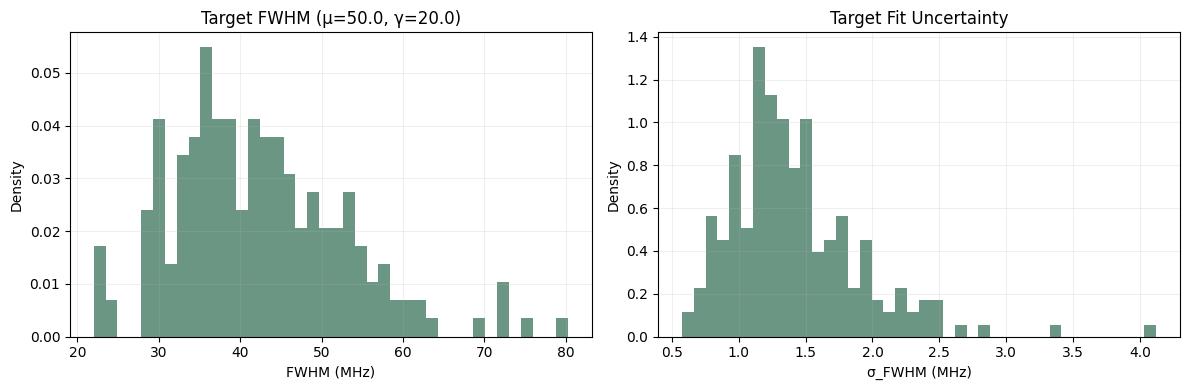

FWHM mean=42.3, sigma mean=1.42 (6s)


In [3]:
t_total = time.time()

# Build fit/nll/fwhm wrappers (Lorentzian, no background)
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

print(f"Generating target ({N_TARGET} runs)...", end=" ", flush=True)
rng = np.random.default_rng(SEED)
target_fwhms, target_sigmas = [], []

for ti in range(N_TARGET):
    if ti % 100 == 0:
        print(f'{ti}...', end=' ', flush=True)
    u, b, n = draw_fixed_noise(NBAR_TRUE, 6, LAMBDA_, rng)
    fw, sig, _ = compute_fwhm_and_dgamma(
        GAMMA_TRUE, u.numpy(), b.numpy(),
        _fit_fn, _fwhm_fn, _nll_fn, n_params=2
    )
    target_fwhms.append(fw)
    target_sigmas.append(sig)

target_t = torch.tensor(target_fwhms, dtype=torch.float32)
target_s_t = torch.tensor(target_sigmas, dtype=torch.float32)
st, _ = torch.sort(target_t)
st_sig, _ = torch.sort(target_s_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(target_t.numpy(), bins=40, density=True, alpha=0.7, color='#2d6a4f')
ax1.set_xlabel('FWHM (MHz)'); ax1.set_ylabel('Density')
ax1.set_title(f'Target FWHM (μ={NBAR_TRUE}, γ={GAMMA_TRUE})')
ax1.grid(alpha=0.2)
ax2.hist(target_s_t.numpy(), bins=40, density=True, alpha=0.7, color='#2d6a4f')
ax2.set_xlabel('σ_FWHM (MHz)'); ax2.set_ylabel('Density')
ax2.set_title('Target Fit Uncertainty')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"FWHM mean={target_t.mean():.1f}, sigma mean={target_s_t.mean():.2f} ({time.time()-t_total:.0f}s)")

## Joint Optimization: FWHM + Sigma

### μ update (REINFORCE)
Per-quantile reward combines FWHM and sigma matches:
```
r_i = −|FWHM_(i) − target_(i)| − λ_sig · |σ_(i) − σ_target_(i)|
adv_i = r_i − baseline
∇_μ = mean(adv_i × (n_i − μ) / σ²)
```

### γ update (implicit diff + CRLB)
```
∇γ_FWHM  = mean(sign(FWHM_i − target_i) × dFWHM_i/dγ)
∇γ_sigma = mean(sign(σ_i − σ_target_i) × dσ_i/dγ)    # dσ/dγ ≈ 2/√n
∇γ = ∇γ_FWHM + λ · ∇γ_sigma
```

In [4]:
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
bl = 0.0
history = []

print(f"μ_init={MU_INIT}, γ_init={GAMMA_INIT}, true=({NBAR_TRUE},{GAMMA_TRUE})")
print(f"N_ITER={N_ITER}, N_RUNS={N_RUNS}, λ_sig={LAMBDA_SIGMA}, λ_γ_sig={LAMBDA_GAMMA_SIGMA}\n")

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, ns = [], [], [], []
    
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        ns.append(n)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw)
        sigmas.append(sig)
        dfs.append(dg)
    
    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    
    # Sorted quantile matching
    sf, sidx = torch.sort(ft)
    pl = torch.abs(sf - st[:N_RUNS])           # FWHM loss per quantile
    nss = nt[sidx]                               # n sorted by FWHM rank
    dgs = dg_t[sidx]                             # dFWHM/dγ sorted by FWHM rank
    ss = si_t[sidx]                              # σ sorted by FWHM rank
    
    # Sigma loss per quantile (same sort order)
    pl_sig = torch.abs(ss - st_sig[:N_RUNS])
    
    # Combined loss
    loss_fwhm = pl.mean()
    loss_sigma = pl_sig.mean()
    mean_loss = (loss_fwhm + LAMBDA_SIGMA * loss_sigma).item()
    loss_fwhm_val = loss_fwhm.item()
    loss_sigma_val = loss_sigma.item()
    
    # Baseline
    if step == 0:
        bl = mean_loss
    else:
        bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss
    
    # ---- MU gradient: REINFORCE with FWHM + sigma reward ----
    per_run_reward = -(pl.detach() + LAMBDA_SIGMA * pl_sig.detach())
    adv = (per_run_reward - bl).numpy()
    scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
    raw_grad_mu = float(np.mean(adv * scores))
    grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
    mu_val += LR_MU * (-grad_mu)
    mu_val = max(1.0, min(200.0, mu_val))
    
    # ---- GAMMA gradient: implicit diff (FWHM) + CRLB (sigma) ----
    # dσ/dγ per run: CRLB ≈ 2/√n
    dsigs = torch.tensor([min(2.0 / math.sqrt(max(int(n), 1)), 2.0) for n in ns], dtype=torch.float32)
    ds_s = dsigs[sidx]
    
    signs_fw = torch.sign(sf - st[:N_RUNS])
    signs_sg = torch.sign(ss - st_sig[:N_RUNS])
    raw_grad_fwhm = float((signs_fw * dgs).mean().item())
    raw_grad_sigma = float((signs_sg * ds_s).mean().item())
    raw_grad_gamma = raw_grad_fwhm + LAMBDA_GAMMA_SIGMA * raw_grad_sigma
    grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
    gamma_val += LR_GAMMA * (-grad_gamma)
    gamma_val = max(0.1, min(100.0, gamma_val))
    
    # Diagnostics
    rho = float(np.corrcoef(nss.numpy(), pl.numpy())[0, 1]) if pl.std() > 0.01 and nss.std() > 0.01 else 0.0
    
    info = {
        'step': step,
        'mu': mu_val, 'gamma': gamma_val,
        'loss': mean_loss, 'loss_fwhm': loss_fwhm_val, 'loss_sigma': loss_sigma_val,
        'baseline': bl,
        'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'rho': rho, 'mean_n': float(np.mean(ns)),
        'mean_fwhm': float(ft.mean().item()),
        'mean_sigma': float(ss.mean().item()),
    }
    history.append(info)
    
    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f} γ={gamma_val:5.1f} | "
              f"L={mean_loss:.2f}(F={loss_fwhm_val:.2f}+S={loss_sigma_val:.2f}) | "
              f"∇μ={grad_mu:+.4f} ∇γ={grad_gamma:+.4f} | "
              f"n̄={info['mean_n']:4.1f} ρ={rho:+.3f} "
              f"({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=8.0, γ_init=5.0, true=(50.0,20.0)
N_ITER=80, N_RUNS=200, λ_sig=0.1, λ_γ_sig=0.1



  S 0: μ= 10.74 γ=  5.5 | L=29.52(F=27.91+S=16.12) | ∇μ=-0.9123 ∇γ=-1.0169 | n̄= 8.8 ρ=-0.050 (10s)


  S 5: μ=  3.33 γ=  9.2 | L=27.18(F=26.45+S=7.35) | ∇μ=+1.0538 ∇γ=-1.2124 | n̄= 6.5 ρ=-0.171 (39s)


  S10: μ=  9.71 γ= 11.4 | L=29.58(F=27.95+S=16.28) | ∇μ=-2.7683 ∇γ=-1.0454 | n̄= 3.5 ρ=-0.116 (55s)


  S15: μ=  2.37 γ= 12.7 | L=29.50(F=28.56+S=9.34) | ∇μ=+0.7679 ∇γ=-0.6051 | n̄= 5.4 ρ=-0.251 (72s)


...

  S65: μ=  5.80 γ= 15.1 | L=27.30(F=25.94+S=13.53) | ∇μ=-1.0047 ∇γ=+0.1255 | n̄= 3.7 ρ=-0.064 (289s)


  S70: μ=  4.52 γ= 15.3 | L=29.38(F=28.32+S=10.51) | ∇μ=-0.7887 ∇γ=-0.7117 | n̄= 3.3 ρ=-0.151 (305s)


  S75: μ=  5.43 γ= 15.1 | L=28.34(F=27.36+S=9.83) | ∇μ=+0.0126 ∇γ=+0.0924 | n̄= 6.5 ρ=-0.201 (329s)


  S79: μ=  4.77 γ= 15.5 | L=26.00(F=24.62+S=13.81) | ∇μ=-0.0456 ∇γ=-0.2052 | n̄= 5.6 ρ=-0.205 (345s)



Done. 345s


## Results

In [5]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*65}")
    print(f"  JOINT OPTIMIZATION — FWHM + SIGMA MATCHING")
    print(f"{'='*65}")
    print(f"  μ:     {MU_INIT:.0f} → {fmu:.2f}  (true={NBAR_TRUE})  error={abs(fmu-NBAR_TRUE):.2f}")
    print(f"  γ:     {GAMMA_INIT:.0f} → {fga:.2f}  (true={GAMMA_TRUE})  error={abs(fga-GAMMA_TRUE):.2f}")
    print(f"  Loss:  {history[0]['loss']:.2f} → {history[-1]['loss']:.2f}")
    print(f"  FWHM:  {history[0]['loss_fwhm']:.2f} → {history[-1]['loss_fwhm']:.2f}")
    print(f"  Sigma: {history[0]['loss_sigma']:.2f} → {history[-1]['loss_sigma']:.2f}")
    print(f"  μ final grad: {history[-1]['grad_mu']:+.4f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*65}")

  JOINT OPTIMIZATION — FWHM + SIGMA MATCHING
  μ:     8 → 4.77  (true=50.0)  error=45.23
  γ:     5 → 15.47  (true=20.0)  error=4.53
  Loss:  29.52 → 26.00
  FWHM:  27.91 → 24.62
  Sigma: 16.12 → 13.81
  μ final grad: -0.0456
  Time:  345s
